In [ ]:
import zipfile

with zipfile.ZipFile("/content/Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset berjaya diextract!")

Dataset berjaya diextract!


# DKA3223 – AMALI 1 CNN

**Nama:** MUHAMMAD AZRIFF DANIAL BIN JAMAL AMIDY

**Angka Giliran:** PKV0125KA004

## Pernyataan Hak Cipta Dataset

Dataset ini digunakan untuk tujuan pembelajaran dan pentaksiran akademik sahaja.

## Etika Pembangunan AI

- Menghormati privasi data
- Tidak menyalahgunakan model AI
- Menggunakan dataset secara beretika

Mounted at /content/drive
Train folder exists: True
Test folder exists : True
Train classes: ['cats', 'dogs']
Test classes : ['cats', 'dogs']
True
Tesla T4
Peranti digunakan: cuda
[SEDIA] Image transforms telah ditetapkan.
Class names     : ['cats', 'dogs']
Class mapping   : {'cats': 0, 'dogs': 1}
Training images : 120
Testing images  : 99


Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16])


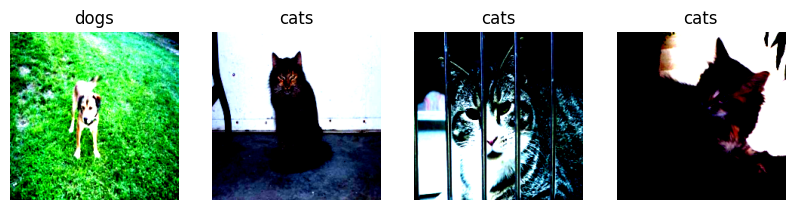

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)
Epoch 1/3: Loss=5.8002, Accuracy=0.5417
Epoch 2/3: Loss=5.2455, Accuracy=0.6250
Epoch 3/3: Loss=5.1058, Accuracy=0.5833
Test Accuracy: 0.5152


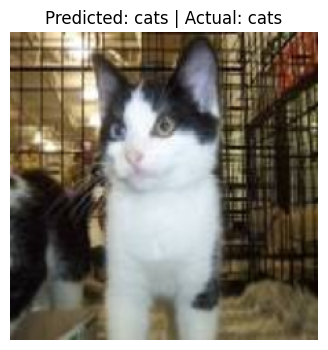

Model disimpan sebagai: /content/drive/MyDrive/Colab Notebooks/kvtron_catdog_cnn_model.pth


In [2]:
# ==============================================================================
# PENTAKSIRAN BERTERUSAN AMALI 1: KV-TRON CNN VISION TRAINING
# KURSUS: DKA3223 - ARTIFICIAL INTELLIGENCE FOR COMPUTER VISION
# ==============================================================================

# LANGKAH 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# LANGKAH 2: Tetapkan Laluan Dataset (FIX ME 1)
import os

# [FIX ME 1]: Gantikan "FIX_ME" dengan laluan folder dataset sebenar dalam Drive anda
dataset_path = "/content/drive/MyDrive/Dataset/Dataset/data_dogcat"  # Contoh: "/content/drive/MyDrive/KVTRON_CNN_Dataset"

if dataset_path == "FIX ME":
    print("[BELUM LENGKAP] Gantikan dataset_path dengan lokasi folder sebenar.")
else:
    train_dir = dataset_path + "/train"
    test_dir = dataset_path + "/test"
    print("Train folder exists:", os.path.exists(train_dir))
    print("Test folder exists :", os.path.exists(test_dir))
    if os.path.exists(train_dir): print("Train classes:", os.listdir(train_dir))
    if os.path.exists(test_dir): print("Test classes :", os.listdir(test_dir))

# Import Pustaka PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Peranti digunakan:", device)

# LANGKAH 3: Konfigurasi Transformasi Imej (Image Transforms)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
print("[SEDIA] Image transforms telah ditetapkan.")

# LANGKAH 4: Memuatkan Dataset Menggunakan ImageFolder
if "train_dir" not in globals() or "test_dir" not in globals():
    print("[BELUM SEDIA] Lengkapkan dataset_path dahulu.")
    train_dataset = test_dataset = None
else:
    train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
    print("Class names     :", train_dataset.classes)
    print("Class mapping   :", train_dataset.class_to_idx)
    print("Training images :", len(train_dataset))
    print("Testing images  :", len(test_dataset))

# LANGKAH 5: Membina DataLoader & Visualisasi Sampel
if train_dataset is None or test_dataset is None:
    print("[BELUM SEDIA] Load dataset dahulu.")
    train_loader = test_loader = None
else:
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    images, labels = next(iter(train_loader))
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)

    plt.figure(figsize=(10,4))
    for i in range(min(4, len(images))):
        image = images[i].permute(1,2,0)
        class_name = train_dataset.classes[labels[i].item()]
        plt.subplot(1,4,i+1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")
    plt.show()

# LANGKAH 6: Pembinaan Model CNN (FIX ME 2)
# [FIX ME 2]: Nyatakan bilangan saluran masukan (RGB) dan bilangan kelas output
INPUT_CHANNELS = 3  # Nyatakan integer yang betul
OUTPUT_CLASSES = 2  # Nyatakan integer yang betul

class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        if INPUT_CHANNELS is None or OUTPUT_CLASSES is None:
            raise ValueError("Lengkapkan INPUT_CHANNELS dan OUTPUT_CLASSES dahulu.")

        self.features = nn.Sequential(
            nn.Conv2d(INPUT_CHANNELS, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, OUTPUT_CLASSES)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

try:
    model = CatDogCNN().to(device)
    print(model)
except Exception as e:
    model = None
    print("[BELUM LENGKAP]", e)

# LANGKAH 7: Tetapan Latihan Model / Hyperparameters (FIX ME 3)
if model is None:
    print("[BELUM SEDIA] Lengkapkan model dahulu.")
    criterion = optimizer = epochs = None
else:
    # [FIX ME 3]: Definisi fungsi kerugian, pengoptimum Adam (lr=0.001), dan epoch=3
    criterion = nn.CrossEntropyLoss()  # Tetapkan fungsi CrossEntropyLoss
    optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
  # Tetapkan pengoptimum Adam untuk model.parameters()
    epochs = 3     # Tetapkan integer epoch (contoh: 3)

    if criterion is None or optimizer is None or epochs is None:
        print("[BELUM LENGKAP] Lengkapkan criterion, optimizer dan epochs.")

# LANGKAH 8: Gelung Latihan (Training Loop)
if model is None or train_loader is None or criterion is None or optimizer is None or epochs is None:
    print("[BELUM SEDIA] Lengkapkan dataset, model dan training setup dahulu.")
    training_complete = False
else:
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total if total else 0
        print(f"Epoch {epoch+1}/{epochs}: Loss={running_loss:.4f}, Accuracy={accuracy:.4f}")

    training_complete = True

# LANGKAH 9: Penilaian Model dan Infrans Imej Tunggal
if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_accuracy = correct / total if total else 0
    print("Test Accuracy:", f"{test_accuracy:.4f}")

    # Ujian Infrans Imej Pertama
    image, actual_label = test_dataset[0]
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        predicted_label = torch.argmax(output, dim=1).item()

    predicted_class = test_dataset.classes[predicted_label]
    actual_class = test_dataset.classes[actual_label]

    plt.figure(figsize=(4,4))
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Predicted: {predicted_class} | Actual: {actual_class}")
    plt.axis("off")
    plt.show()

# LANGKAH 10: Menyimpan Model (.pth) ke Google Drive
save_dir = "/content/drive/MyDrive/Colab Notebooks"
save_path = os.path.join(save_dir, "kvtron_catdog_cnn_model.pth")

if globals().get("training_complete", False):
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print("Model disimpan sebagai:", save_path)
else:
    print("Model belum disimpan kerana training_complete masih False.")

